In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, widgets
import numpy as np

In [22]:
# En esta celda se cargan los datos y se muestra un resumen de los mismos. 
# Se utiliza la biblioteca seaborn para configurar el estilo de los graficos.
# Se usa pandas para cargar el archivo CSV que contiene las emisiones de CO2 per capita y se muestra el contenido del DataFame resultante.

sns.set(style='whitegrid')
data = pd.read_csv('co2-emissions-per-capita.csv')
data

,Entity,Code,Year,CO₂ emissions per capita
0,Afghanistan,AFG,1949,0.001992
1,Afghanistan,AFG,1950,0.010837
2,Afghanistan,AFG,1951,0.011625
3,Afghanistan,AFG,1952,0.011468
4,Afghanistan,AFG,1953,0.013123
...,...,...,...,...
26504,Zimbabwe,ZWE,2020,0.546847
26505,Zimbabwe,ZWE,2021,0.647125
26506,Zimbabwe,ZWE,2022,0.761205
26507,Zimbabwe,ZWE,2023,0.822681


In [23]:
# En esta celda se filtran los datos para incluir solo los paises que se desean analizar.
# Se crea una lista de paises y se utiliza el metodo isin() para filtrar el DataFrame original creando uno nuevo que solo continue los datos de los paises seleccionados.
# Finalmente, se muestra el DataFrame filtrado.

countries = ['United States', 'China', 'India', 'United Kingdom', 'Mexico', 'Peru', 'Colombia']
filtered_data = data[data['Entity'].isin(countries)].copy()
filtered_data

,Entity,Code,Year,CO₂ emissions per capita
4896,China,CHN,1907,0.048403
4897,China,CHN,1908,0.055021
4898,China,CHN,1909,0.058310
4899,China,CHN,1910,0.059680
4900,China,CHN,1911,0.058271
...,...,...,...,...
25099,United States,USA,2020,13.816895
25100,United States,USA,2021,14.758024
25101,United States,USA,2022,14.802047
25102,United States,USA,2023,14.319450


In [24]:
# Se muestra el rango de años disponibles en el DataFrame filtrado utilizando los metodos min() y max() para obtener el año minimo y maximo.

print(f"Años disponibles: {filtered_data['Year'].min()} - {filtered_data['Year'].max()}")

Años disponibles: 1750 - 2024


In [25]:
# Se verifica si hay valores nulos filtrando los datos de los paises seleccionados y utilizando el metodo isnull() junto con sum() para contar el numero de valores nulos por columna.

print('Valores nulos por columna: ')
print(filtered_data.isnull().sum())

Valores nulos por columna: 
Entity                      0
Code                        0
Year                        0
CO₂ emissions per capita    0
dtype: int64


c:\Users\yolic\OneDrive\Desktop\Practicas_y_ejercicios_Datos_y_programacion\pythonenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


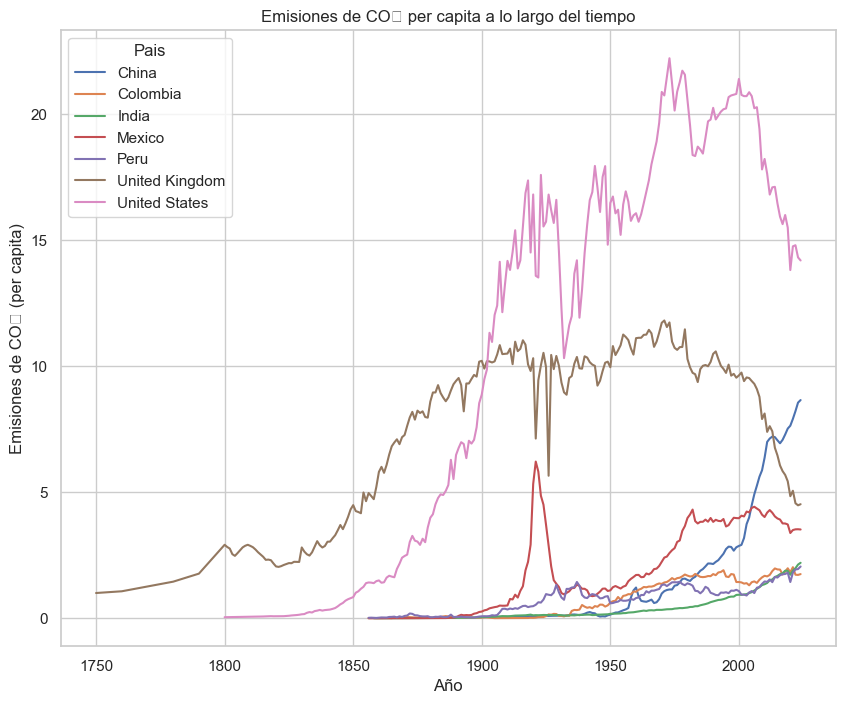

In [26]:
# Se crea un grafico de lineas utilizando seaborn para mostrar las emisiones de CO2 per capita a lo largo del tiempo para los paises seleccionados.
# Se usa matplotlib para configurar el tamaño del grafico, agregar titulos y etiquetas a los ejes, y mostrar la leyenda que indica a que pais corresponde cada linea.

plt.figure(figsize=(10,8))
sns.lineplot(data=filtered_data, x='Year', y='CO₂ emissions per capita', hue='Entity')
plt.title('Emisiones de CO₂ per capita a lo largo del tiempo')
plt.xlabel('Año')
plt.ylabel('Emisiones de CO₂ (per capita)')
plt.legend(title='Pais')
plt.show()

In [27]:
# Se agrega una nueva columna al DataFrame filtrando que representa la decada a la que corresponde cad año.
# Luego, se filtran los datos para incluir solo las decadas a partir de 1950.
# Por ultimo, se calcula el promedio de emisiones por cada decada para cada pais utilizando el metodo groupby() y mean(), y se muestra el resultado.

filtered_data.loc[:, 'Decade'] = (filtered_data['Year']//10)*10
decade_data = filtered_data[filtered_data['Decade'] >= 1950]
decade_avg = decade_data.groupby(['Entity', 'Decade'])['CO₂ emissions per capita'].mean().reset_index()

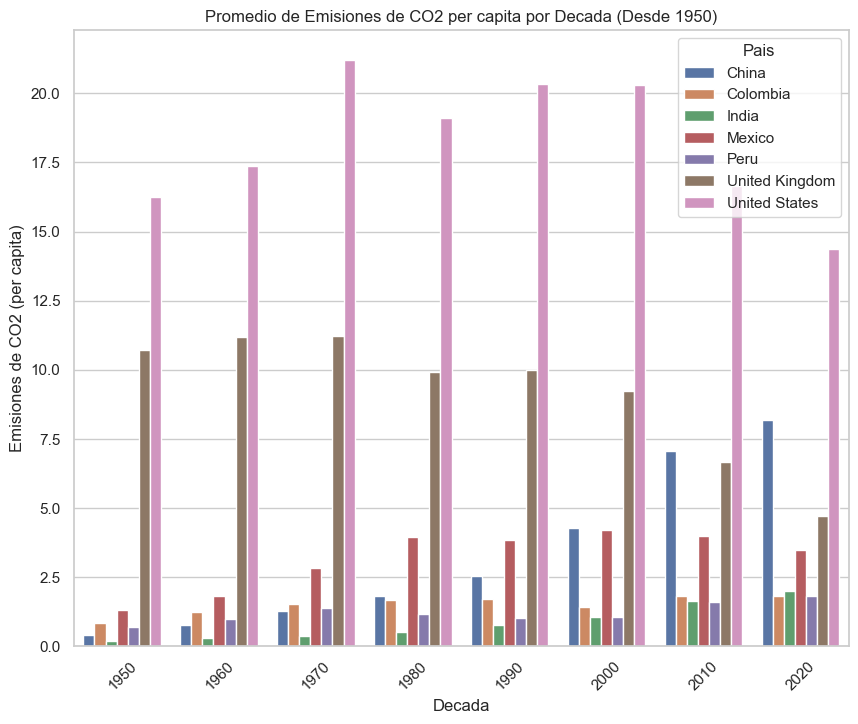

In [28]:
# Se crea una grafica de barras para mostrar el promedio de emisiones de CO2 per capita por decada para cada pais.

plt.figure(figsize=(10, 8))
sns.barplot(data=decade_avg, x='Decade', y='CO₂ emissions per capita', hue='Entity')
plt.xticks(rotation=45) #Rotar etiquetas del eje X
plt.title('Promedio de Emisiones de CO2 per capita por Decada (Desde 1950)')
plt.xlabel('Decada')
plt.ylabel('Emisiones de CO2 (per capita)')
plt.legend(title='Pais')
plt.show()

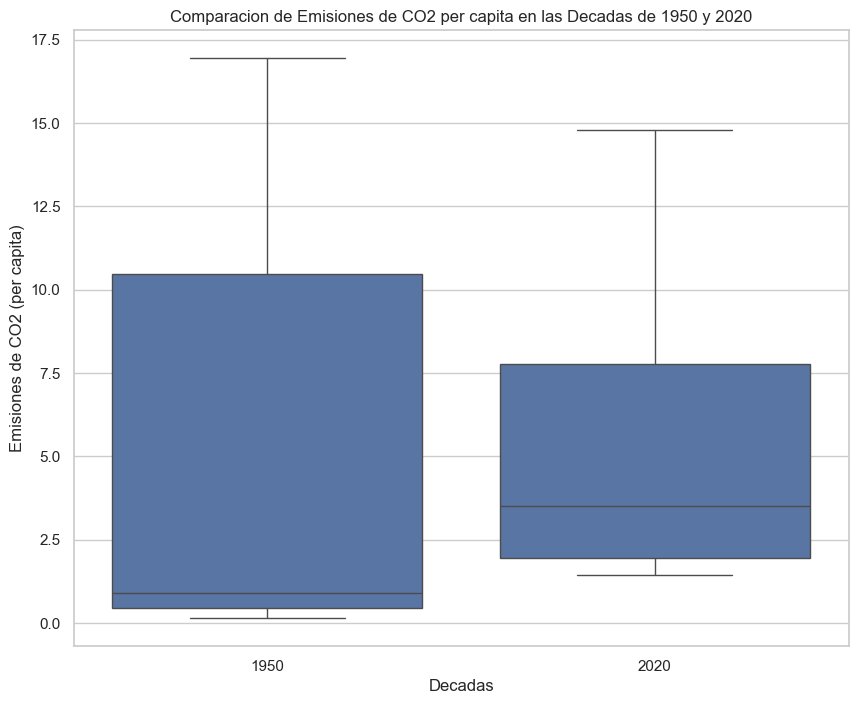

In [29]:
# Se filtran los datos para incluir solo las decadas de 1950 y 2020.
# Se crea una nueva columna 'Decade Label' para mostrar las decadas como etiquetas en el grafico.

decades_1950_2020 = filtered_data [filtered_data['Decade'].isin([1950, 2020])].copy()
decades_1950_2020.loc[:, 'Decade Label'] = decades_1950_2020['Decade'].astype(str)

# Se crea un grafico de cajas para comparar las emisiones de CO2 per capita entre las decadas de 1950 y 2020 para los paises seleccionados.

plt.figure(figsize=(10, 8))
sns.boxplot(data = decades_1950_2020, x = 'Decade Label', y = 'CO₂ emissions per capita')
plt.title('Comparacion de Emisiones de CO2 per capita en las Decadas de 1950 y 2020')
plt.xlabel('Decadas')
plt.ylabel('Emisiones de CO2 (per capita)')
plt.show()

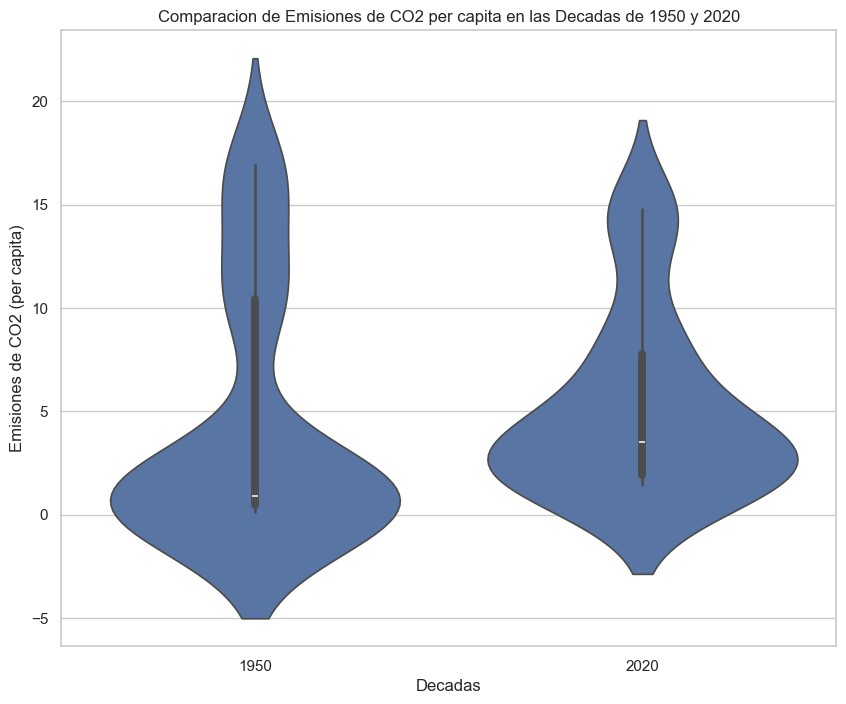

In [30]:
# Se crea un grafico de violines para comparar la distribucion de las emisiones de CO2 per capita entre las decadas de 1950 y 2020 para los paises seleccionados.

plt.figure(figsize=(10, 8))
sns.violinplot(data = decades_1950_2020, x = 'Decade Label', y = 'CO₂ emissions per capita')
plt.title('Comparacion de Emisiones de CO2 per capita en las Decadas de 1950 y 2020')
plt.xlabel('Decadas')
plt.ylabel('Emisiones de CO2 (per capita)')
plt.show()

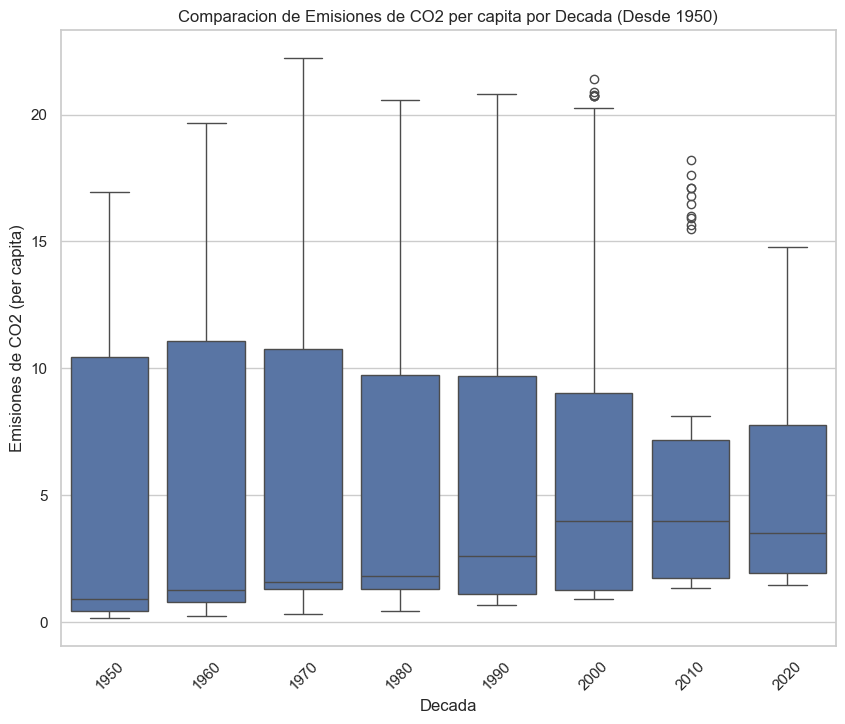

In [31]:
# Se crea una variable que contiene los datos de todas las decadas a partir de 1950.

all_decades_data = filtered_data[filtered_data['Decade'] >= 1950]

# Con la variable creada, se genera un grafico de cajas para comparar las emisiones de CO2 per capita entre todas las deadas a partir de 1950 para los paises seleccionados.

plt.figure(figsize=(10, 8))
sns.boxplot(data = all_decades_data, x = 'Decade', y = 'CO₂ emissions per capita')
plt.title('Comparacion de Emisiones de CO2 per capita por Decada (Desde 1950)')
plt.xlabel('Decada')
plt.ylabel('Emisiones de CO2 (per capita)')
plt.xticks(rotation= 45)
plt.show()

In [32]:
# Se crea una tabla pivote para mostrar las emisiones de CO2 per capita por año para cada pais seleccionado.

pivot_data = filtered_data.pivot(index='Year', columns='Entity', values='CO₂ emissions per capita')
pivot_data.head()

Entity,China,Colombia,India,Mexico,Peru,United Kingdom,United States
Year,,,,,,,
1750,NaN,NaN,NaN,NaN,NaN,1.001912,NaN
1760,NaN,NaN,NaN,NaN,NaN,1.070363,NaN
1770,NaN,NaN,NaN,NaN,NaN,1.262799,NaN
1780,NaN,NaN,NaN,NaN,NaN,1.452038,NaN
1790,NaN,NaN,NaN,NaN,NaN,1.770789,NaN


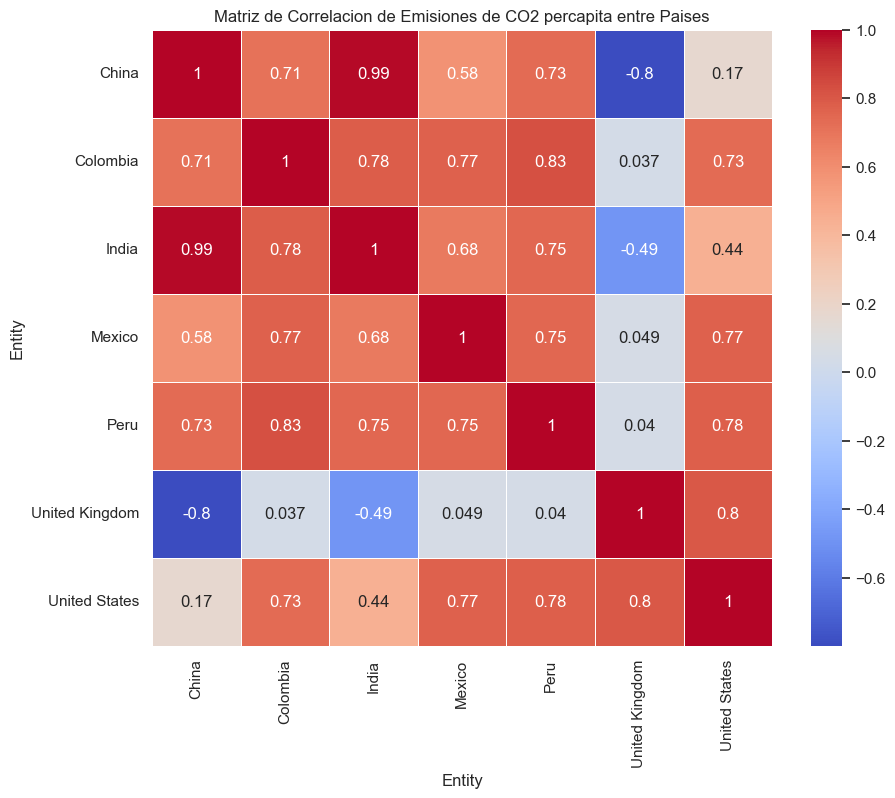

In [33]:
# Se calcula la matriz de correlacion entre las emisiones de los paises utilizando el metodo corr() de pandas, que calcula la correlacion entre las columnas del DataFrame pivoteado.

correlation_matrix = pivot_data.corr()

# Se crea un mapa de calor utilizando seaborn para visualizar la matriz de correlacion entre las emisiones de CO2 per capita entre los paises seleccionados.

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlacion de Emisiones de CO2 percapita entre Paises')
plt.show()

In [34]:
# Se crea una funcion que resive dos paises
def scatter_plot_dynamic(country1, country2, trendline=False):
    # Se crea una condicion para mostrar un mensaje en caso de que ambos paises elejidos sean iguales.
    if country1 == country2:
        print('Selecione dos paises diferentes para comparar.')
        return
    
    # Se filtran los datos para los dos paises seleccionados
    data1 = filtered_data[filtered_data['Entity'] == country1]
    data2 = filtered_data[filtered_data['Entity'] == country2]

    # Se combinan los datos en un solo dataframe por año
    merged_data = data1[['Year', 'CO₂ emissions per capita']].merge(
        data2[['Year', 'CO₂ emissions per capita']],
        on='Year', suffixes=(f"_{country1}", f"_{country2}")
    )

    # Calcular el coeficiente de correlacion
    correlation = merged_data[f"CO₂ emissions per capita_{country1}"].corr(
        merged_data[f"CO₂ emissions per capita_{country2}"]
    )

    # Se grafica el diagra,a de dispersion
    plt.figure(figsize=(10, 8)) 
    sns.scatterplot(data=merged_data,
                    x=f"CO₂ emissions per capita_{country1}",
                    y=f"CO₂ emissions per capita_{country2}")
    
    plt.title(f"Relacion entre Emisiones de CO2 percapita de {country1} y {country2} \nCoeficiente de Correlacion: {correlation}")
    plt.xlabel(f"Emisiones de CO2 per capita - {country1}")
    plt.ylabel(f"Emisiones de CO2 per capita - {country2}")
    
    # Se agrega la linea de tendencia
    if trendline:
        # Se calcula la linea de tendencia
        x = merged_data[f"CO₂ emissions per capita_{country1}"]
        y = merged_data[f"CO₂ emissions per capita_{country2}"]
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m * x+b, color = 'red', linestyle = '--', label = f"Tendencia (y = {m:.2f}x + {b:.2f})")
        plt.legend()

    plt.show()

In [35]:
# Se crea un widget interactivo para seleccionar los paises y la opcion de lineade tendencia.
interact(scatter_plot_dynamic,
         country1 = widgets.Dropdown(options=countries, description='Pais 1', value='United States'),
         country2 = widgets.Dropdown(options=countries, description='Pais 2', value='Mexico'),
         trendline = widgets.Checkbox(values=False, description='Mostrar linea de tendencia'))

interactive(children=(Dropdown(description='Pais 1', options=('United States', 'China', 'India', 'United Kingd…

<function __main__.scatter_plot_dynamic(country1, country2, trendline=False)>